In [15]:

import pandas as pd

df_raw = pd.read_csv('india_monthly_full_release_long_format.csv')
print(f" Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")




query = """
    SELECT State, Date, Variable, Unit, Value
    FROM electricity_data
    WHERE Variable = 'Total Generation'
      AND Unit = 'GWh'
      AND State = 'India Total'
    LIMIT 10
"""
print(sample.to_string(index=False))

conn.close()


 Dataset loaded: 238,200 rows × 13 columns
      State       Date         Variable Unit     Value
India Total 01-01-2019 Total Generation  GWh 110268.43
India Total 01-02-2019 Total Generation  GWh 100838.65
India Total 01-03-2019 Total Generation  GWh 117111.22
India Total 01-04-2019 Total Generation  GWh 118905.47
India Total 01-05-2019 Total Generation  GWh 129132.22
India Total 01-06-2019 Total Generation  GWh 126546.50
India Total 01-07-2019 Total Generation  GWh 123708.34
India Total 01-08-2019 Total Generation  GWh 119935.29
India Total 01-09-2019 Total Generation  GWh 114787.86
India Total 01-10-2019 Total Generation  GWh 105698.24


In [16]:


import pandas as pd
import numpy as np



df = pd.read_csv('india_monthly_full_release_long_format.csv')


print("DATASET OVERVIEW")

print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

print(df.head())


DATASET OVERVIEW
Shape        : 238,200 rows × 13 columns
Memory Usage : 140.9 MB

  Country Country code                State State code       State type  \
0   India          IND  Andaman and Nicobar         AN  Union territory   
1   India          IND  Andaman and Nicobar         AN  Union territory   
2   India          IND  Andaman and Nicobar         AN  Union territory   
3   India          IND  Andaman and Nicobar         AN  Union territory   
4   India          IND  Andaman and Nicobar         AN  Union territory   

         Date  Category     Subcategory  \
0  01-01-2019  Capacity  Aggregate fuel   
1  01-01-2019  Capacity  Aggregate fuel   
2  01-01-2019  Capacity  Aggregate fuel   
3  01-01-2019  Capacity  Aggregate fuel   
4  01-01-2019  Capacity  Aggregate fuel   

                                Variable Unit  Value  YoY absolute change  \
0                                  Clean   MW    NaN                  NaN   
1                                 Fossil   MW    NaN 

In [17]:


df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')  # e.g., Jan, Feb

print(" Date column parsed. Sample:")
print(df[['Date', 'Year', 'Month', 'Month_Name']].head())


print("\n Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


before = len(df)
df_clean = df.dropna(subset=['Value']).copy()
after = len(df_clean)
print(f"\n Dropped {before - after:,} rows with missing 'Value' ({(before-after)/before*100:.1f}%)")
print(f"   Remaining rows: {after:,}")


df_clean['YoY absolute change'] = df_clean['YoY absolute change'].fillna(0)
df_clean['YoY % change']        = df_clean['YoY % change'].fillna(0)
print("YoY columns: NaN filled with 0")

print("\n Final Data Types:")
print(df_clean.dtypes)


 Date column parsed. Sample:
        Date  Year  Month Month_Name
0 2019-01-01  2019      1        Jan
1 2019-01-01  2019      1        Jan
2 2019-01-01  2019      1        Jan
3 2019-01-01  2019      1        Jan
4 2019-01-01  2019      1        Jan

 Missing Values per Column:
                     Missing Count  Missing %
Value                         3513       1.47
YoY absolute change         116157      48.76
YoY % change                163607      68.68

 Dropped 3,513 rows with missing 'Value' (1.5%)
   Remaining rows: 234,687
YoY columns: NaN filled with 0

 Final Data Types:
Country                           str
Country code                      str
State                             str
State code                        str
State type                        str
Date                   datetime64[us]
Category                          str
Subcategory                       str
Variable                          str
Unit                              str
Value                        

In [18]:



# ── Total Electricity Generation (GWh) for all India ─────────────────────────
df_india = df_clean[
    (df_clean['State']    == 'India Total') &
    (df_clean['Variable'] == 'Total Generation') &
    (df_clean['Unit']     == 'GWh')
].copy().sort_values('Date').reset_index(drop=True)

print(f"India Total – Total Generation rows: {len(df_india)}")
print(df_india[['Date', 'Year', 'Month', 'Value']].head(10))

# ── Fuel-wise generation (India Total) for comparison ─────────────────────────
fuels = ['Coal', 'Solar', 'Wind', 'Hydro', 'Nuclear', 'Gas']
df_fuel = df_clean[
    (df_clean['State']    == 'India Total') &
    (df_clean['Variable'].isin(fuels)) &
    (df_clean['Unit']     == 'GWh')
].copy()
print(f"\nFuel-wise generation rows: {len(df_fuel)}")
print(df_fuel['Variable'].value_counts())


India Total – Total Generation rows: 83
        Date  Year  Month      Value
0 2019-01-01  2019      1  110268.43
1 2019-02-01  2019      2  100838.65
2 2019-03-01  2019      3  117111.22
3 2019-04-01  2019      4  118905.47
4 2019-05-01  2019      5  129132.22
5 2019-06-01  2019      6  126546.50
6 2019-07-01  2019      7  123708.34
7 2019-08-01  2019      8  119935.29
8 2019-09-01  2019      9  114787.86
9 2019-10-01  2019     10  105698.24

Fuel-wise generation rows: 498
Variable
Coal       83
Gas        83
Hydro      83
Nuclear    83
Solar      83
Wind       83
Name: count, dtype: int64


In [19]:



values = df_india['Value'].values   # Convert to NumPy array


print("NumPy Statistical Operations on Monthly Generation (GWh)")

print(f"  Array shape       : {values.shape}")
print(f"  Mean              : {np.mean(values):>12,.2f} GWh")
print(f"  Median            : {np.median(values):>12,.2f} GWh")
print(f"  Std Deviation     : {np.std(values):>12,.2f} GWh")
print(f"  Variance          : {np.var(values):>12,.2f}")
print(f"  Minimum           : {np.min(values):>12,.2f} GWh")
print(f"  Maximum           : {np.max(values):>12,.2f} GWh")
print(f"  Total (sum)       : {np.sum(values):>12,.2f} GWh")
print(f"  25th Percentile   : {np.percentile(values, 25):>12,.2f} GWh")
print(f"  75th Percentile   : {np.percentile(values, 75):>12,.2f} GWh")





NumPy Statistical Operations on Monthly Generation (GWh)
  Array shape       : (83,)
  Mean              :   132,204.76 GWh
  Median            :   132,124.10 GWh
  Std Deviation     :    17,752.96 GWh
  Variance          : 315,167,451.38
  Minimum           :    91,499.53 GWh
  Maximum           :   167,414.52 GWh
  Total (sum)       : 10,972,994.87 GWh
  25th Percentile   :   118,170.96 GWh
  75th Percentile   :   147,316.60 GWh


In [20]:


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set a clean global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'font.family'   : 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
print(" Visualization libraries ready.")


 Visualization libraries ready.


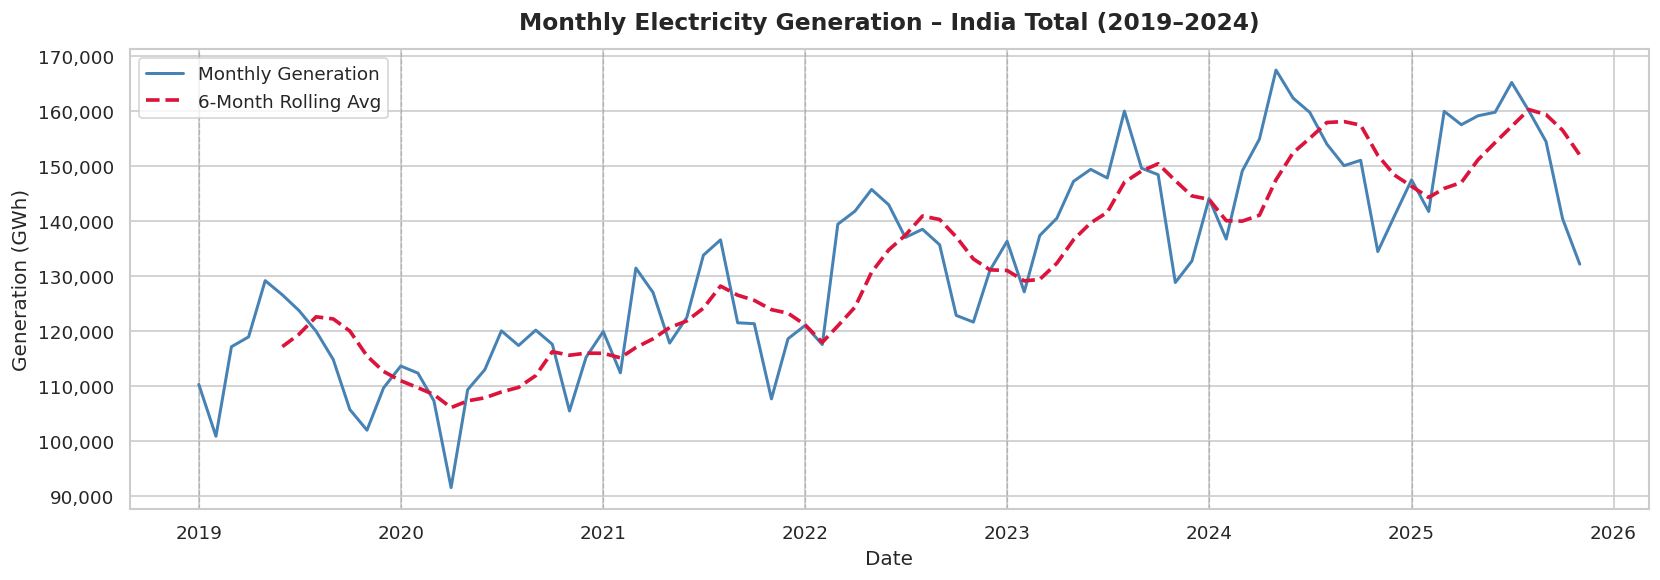

In [21]:
# Unit III – Plot 1: Line Plot – Monthly Electricity Generation Trend

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_india['Date'], df_india['Value'],
        color='steelblue', linewidth=1.8, label='Monthly Generation')

# Highlight year boundaries with vertical dashed lines
for year in df_india['Year'].unique():
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# Add a 6-month rolling average line
rolling_avg = df_india['Value'].rolling(window=6).mean()
ax.plot(df_india['Date'], rolling_avg,
        color='crimson', linewidth=2.2, linestyle='--', label='6-Month Rolling Avg')

ax.set_title("Monthly Electricity Generation – India Total (2019–2024)", fontweight='bold', pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Generation (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plot1_line_trend.png', bbox_inches='tight')
plt.show()


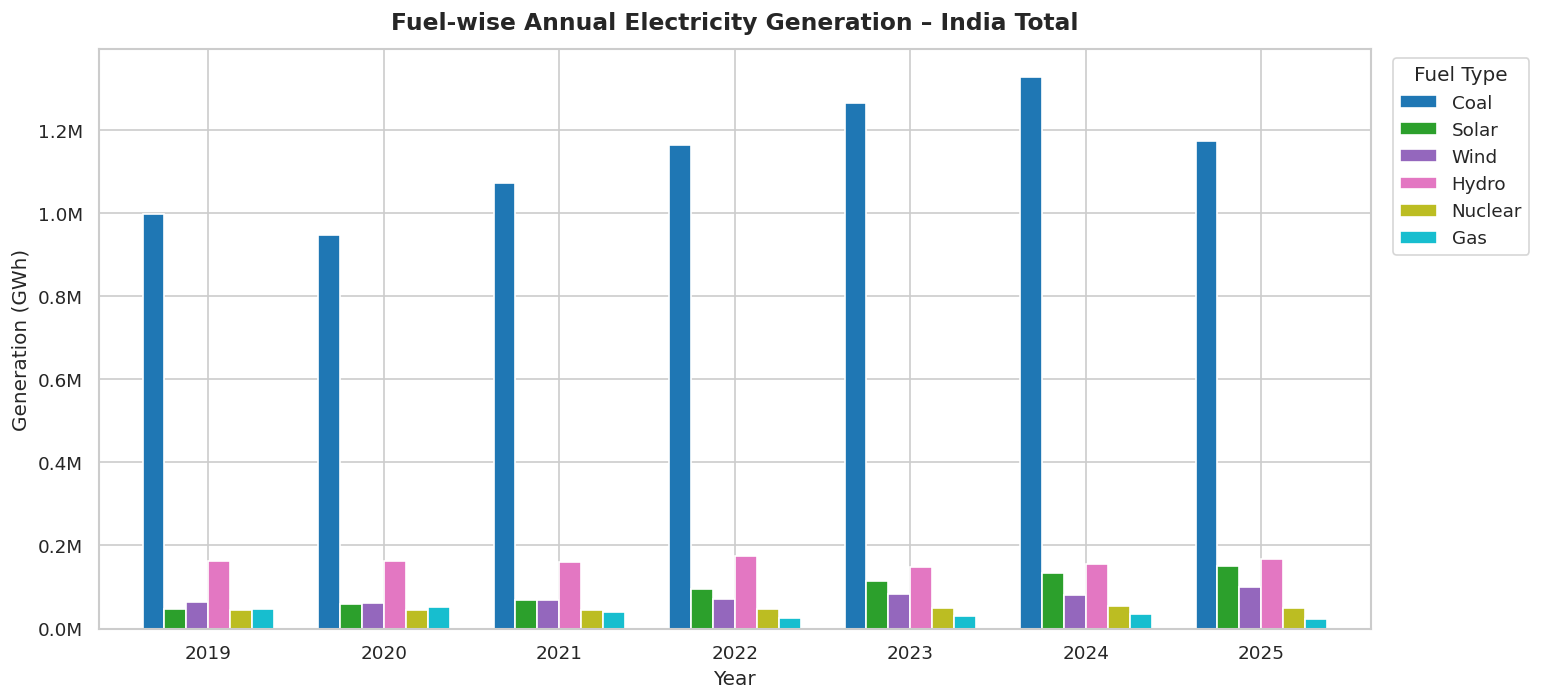

In [22]:
# Unit III – Plot 2: Bar Chart – Fuel-wise Annual Generation

# Aggregate fuel-wise data by year
fuel_yearly = df_fuel.groupby(['Year', 'Variable'])['Value'].sum().reset_index()
fuel_pivot  = fuel_yearly.pivot(index='Year', columns='Variable', values='Value').fillna(0)

# Keep only main fuels and sort columns by total generation
main_fuels = ['Coal', 'Solar', 'Wind', 'Hydro', 'Nuclear', 'Gas']
fuel_pivot = fuel_pivot[[f for f in main_fuels if f in fuel_pivot.columns]]

fig, ax = plt.subplots(figsize=(13, 6))

fuel_pivot.plot(kind='bar', ax=ax, colormap='tab10', width=0.75, edgecolor='white')

ax.set_title("Fuel-wise Annual Electricity Generation – India Total", fontweight='bold', pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Generation (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Fuel Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(fuel_pivot.index, rotation=0)
plt.tight_layout()
plt.savefig('plot2_bar_fuel.png', bbox_inches='tight')
plt.show()


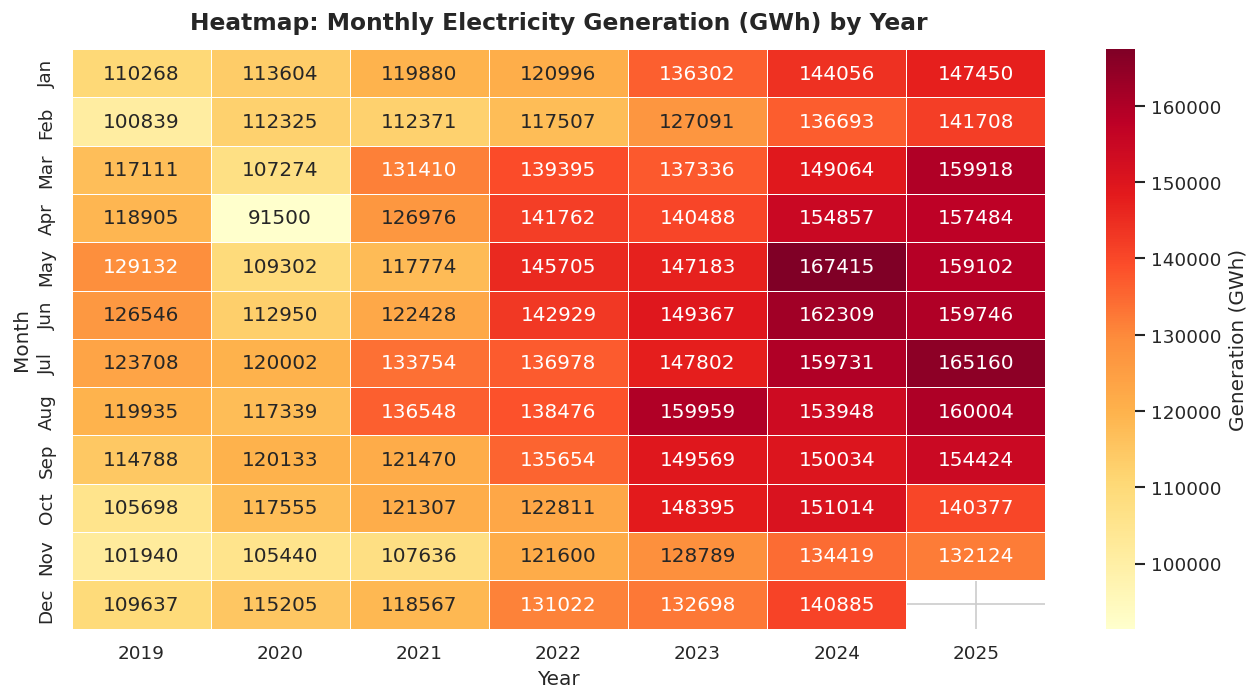

In [23]:
# Unit III – Plot 3: Heatmap – Monthly Generation by Year

# Pivot: rows = Month, columns = Year
heatmap_data = df_india.pivot_table(index='Month', columns='Year', values='Value', aggfunc='sum')
heatmap_data.index = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec'][:len(heatmap_data)]

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Generation (GWh)'},
    ax=ax
)

ax.set_title("Heatmap: Monthly Electricity Generation (GWh) by Year", fontweight='bold', pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig('plot3_heatmap.png', bbox_inches='tight')
plt.show()


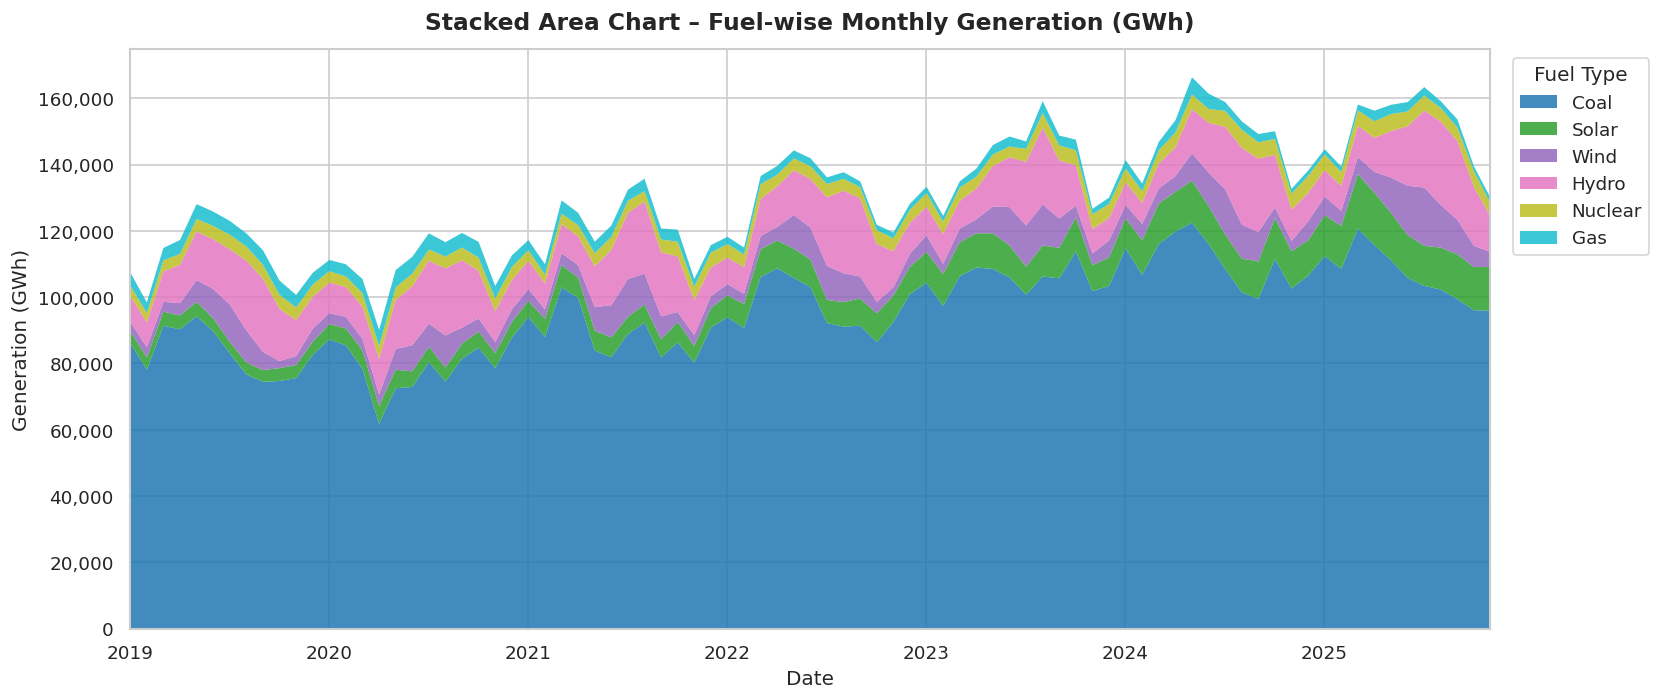

In [24]:
# Unit III – Plot 4: Area Chart – Stacked Fuel Generation Over Time

df_fuel_pivot = df_fuel.pivot_table(index='Date', columns='Variable', values='Value', aggfunc='sum').fillna(0)
df_fuel_pivot = df_fuel_pivot[[f for f in main_fuels if f in df_fuel_pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))

df_fuel_pivot.plot.area(ax=ax, colormap='tab10', alpha=0.85, linewidth=0)

ax.set_title("Stacked Area Chart – Fuel-wise Monthly Generation (GWh)", fontweight='bold', pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Generation (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Fuel Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot4_area_fuels.png', bbox_inches='tight')
plt.show()


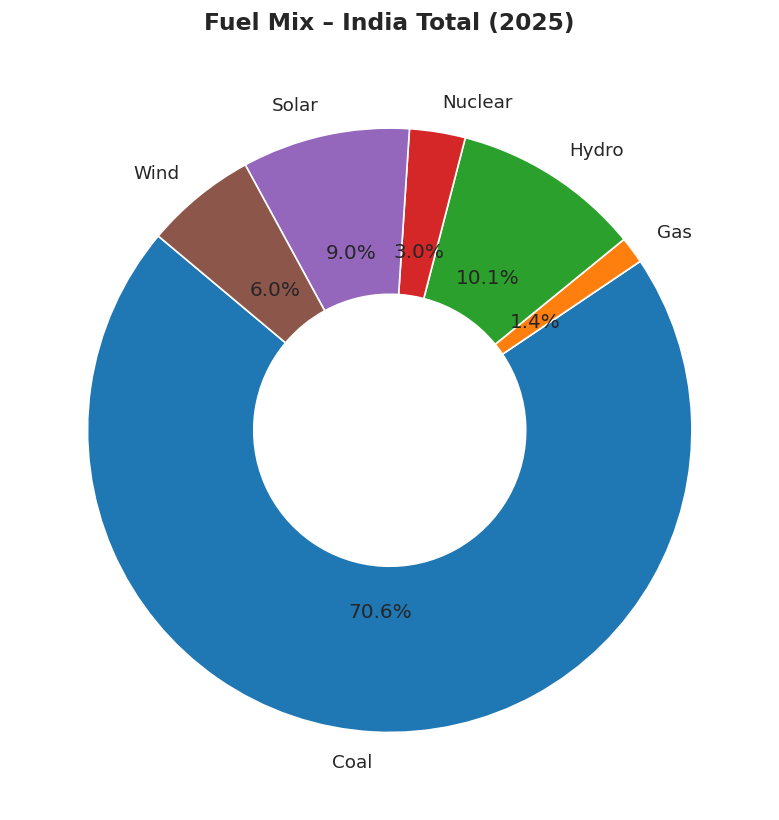

In [25]:
# Unit III – Plot 5: Pie Chart – Share of Each Fuel (Latest Year)

latest_year = df_fuel['Year'].max()
fuel_latest = df_fuel[df_fuel['Year'] == latest_year].groupby('Variable')['Value'].sum()

fig, ax = plt.subplots(figsize=(8, 7))

wedge_props = dict(width=0.55, edgecolor='white')   # donut effect
ax.pie(
    fuel_latest.values,
    labels=fuel_latest.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=wedge_props,
    colors=sns.color_palette('tab10', len(fuel_latest))
)
ax.set_title(f"Fuel Mix – India Total ({latest_year})", fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('plot5_pie_fuelmix.png', bbox_inches='tight')
plt.show()

In [26]:
# Unit IV – Section 1: Summary Statistics


print("SUMMARY STATISTICS – Monthly Generation (GWh), India Total")

print(df_india['Value'].describe().round(2))

print("\nYear-wise Statistics:")
yw = df_india.groupby('Year')['Value'].describe().round(2)
print(yw[['mean','std','min','25%','50%','75%','max']])


SUMMARY STATISTICS – Monthly Generation (GWh), India Total
count        83.00
mean     132204.76
std       17860.88
min       91499.53
25%      118170.96
50%      132124.10
75%      147316.60
max      167414.52
Name: Value, dtype: float64

Year-wise Statistics:
           mean       std        min        25%        50%        75%  \
Year                                                                    
2019  114875.82   9349.64  100838.65  108652.56  115949.54  120878.55   
2020  111885.76   7955.22   91499.53  108795.10  113277.07  117392.64   
2021  122510.13   8496.67  107635.53  118369.20  121388.52  128084.30   
2022  132902.85   9780.42  117507.03  122508.20  136316.27  139986.49   
2023  142081.62   9886.83  127091.33  135401.04  143835.84  148637.66   
2024  150368.65  10122.85  134418.58  143263.43  150523.77  156075.74   
2025  152499.73  10489.88  132124.10  144578.85  157483.89  159832.03   

            max  
Year             
2019  129132.22  
2020  120133.41  
2021  13

Correlation Matrix:
                     Year  Month  Value  YoY absolute change  YoY % change
Year                 1.00  -0.03   0.84                 0.19          0.15
Month               -0.03   1.00  -0.04                -0.02         -0.02
Value                0.84  -0.04   1.00                 0.39          0.33
YoY absolute change  0.19  -0.02   0.39                 1.00          0.99
YoY % change         0.15  -0.02   0.33                 0.99          1.00


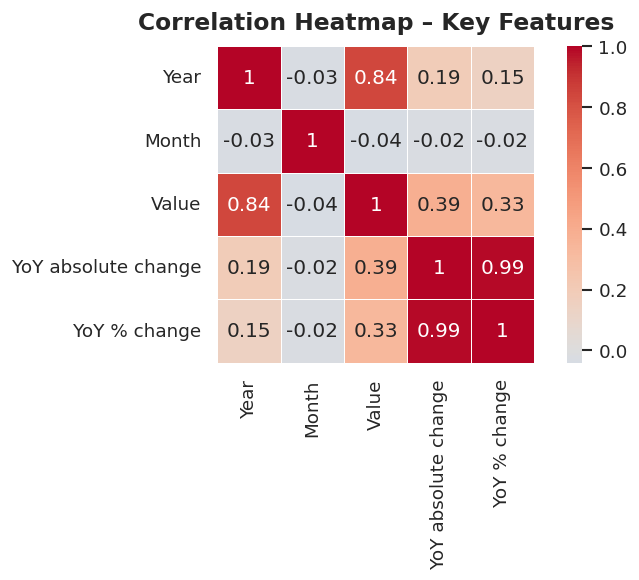

In [27]:
# Unit IV – Section 2: Correlation Analysis

# Build a feature table: Year, Month, Generation, YoY change
corr_df = df_india[['Year', 'Month', 'Value', 'YoY absolute change', 'YoY % change']].copy()

# Also add Fuel columns as features
for fuel in main_fuels:
    sub = df_fuel[df_fuel['Variable'] == fuel][['Date','Value']].rename(columns={'Value': fuel})
    corr_df = corr_df.merge(sub, on='Date', how='left') if False else corr_df  # skip for simplicity

corr_matrix = corr_df.corr(numeric_only=True).round(2)
print("Correlation Matrix:")
print(corr_matrix)

# Heatmap of correlations
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title("Correlation Heatmap – Key Features", fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('plot6_corr_heatmap.png', bbox_inches='tight')
plt.show()



C:\Users\sachin\AppData\Local\Temp\ipykernel_7104\2867438530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_india, x='Year', y='Value', palette='Blues', ax=axes[0])
C:\Users\sachin\AppData\Local\Temp\ipykernel_7104\2867438530.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_india, x='Month_Name', y='Value', order=month_order,


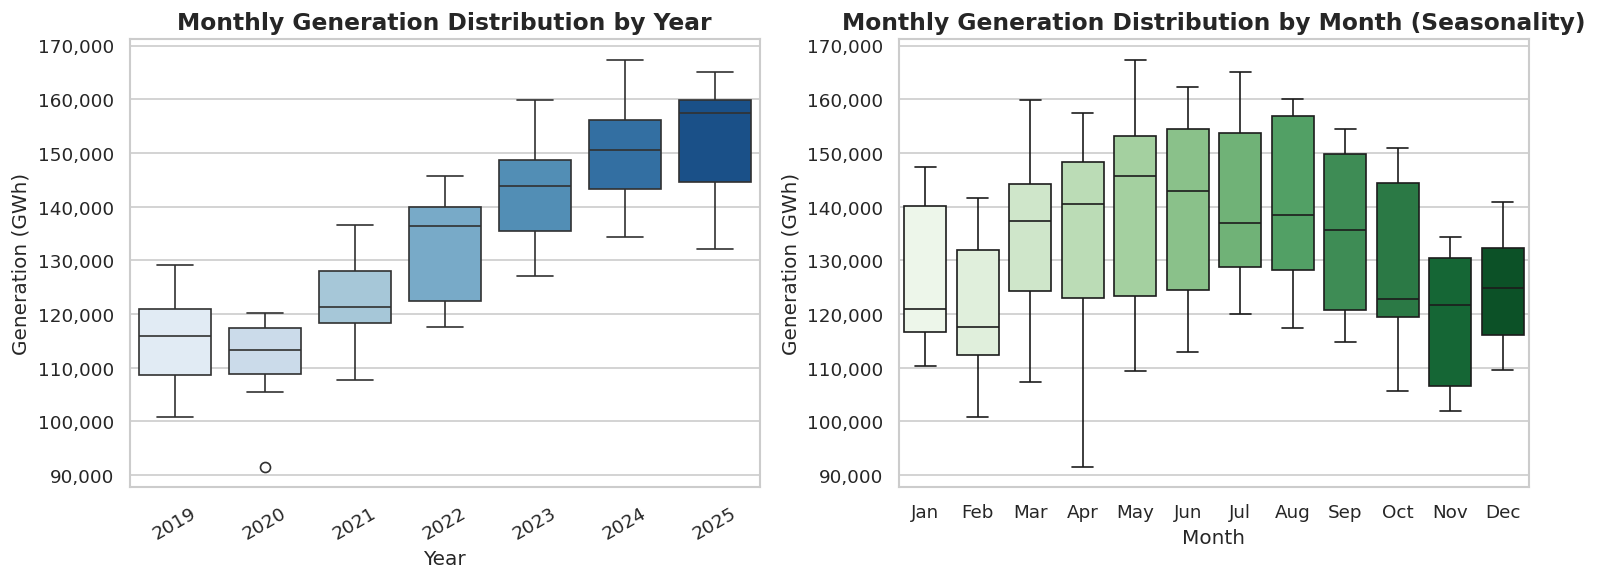


📋 Outlier Detection (IQR Method):
   Lower Bound : 74,452.52 GWh
   Upper Bound : 191,035.04 GWh
   Outliers    : 0 rows
    No significant outliers detected!


In [29]:
# Unit IV – Section 3: Outlier Detection (Boxplot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Box plot by Year ───────────────────────────────────────────────────────────
sns.boxplot(data=df_india, x='Year', y='Value', palette='Blues', ax=axes[0])
axes[0].set_title("Monthly Generation Distribution by Year", fontweight='bold')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Generation (GWh)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

# ── Box plot by Month (seasonality) ───────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df_india, x='Month_Name', y='Value', order=month_order,
            palette='Greens', ax=axes[1])
axes[1].set_title("Monthly Generation Distribution by Month (Seasonality)", fontweight='bold')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Generation (GWh)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('plot7_boxplot.png', bbox_inches='tight')
plt.show()

# ── Detect outliers using IQR method ──────────────────────────────────────────
Q1 = df_india['Value'].quantile(0.25)
Q3 = df_india['Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_india[(df_india['Value'] < lower_bound) | (df_india['Value'] > upper_bound)]
print(f"\n📋 Outlier Detection (IQR Method):")
print(f"   Lower Bound : {lower_bound:,.2f} GWh")
print(f"   Upper Bound : {upper_bound:,.2f} GWh")
print(f"   Outliers    : {len(outliers)} rows")
if len(outliers) > 0:
    print(outliers[['Date', 'Year', 'Month', 'Value']])
else:
    print("    No significant outliers detected!")


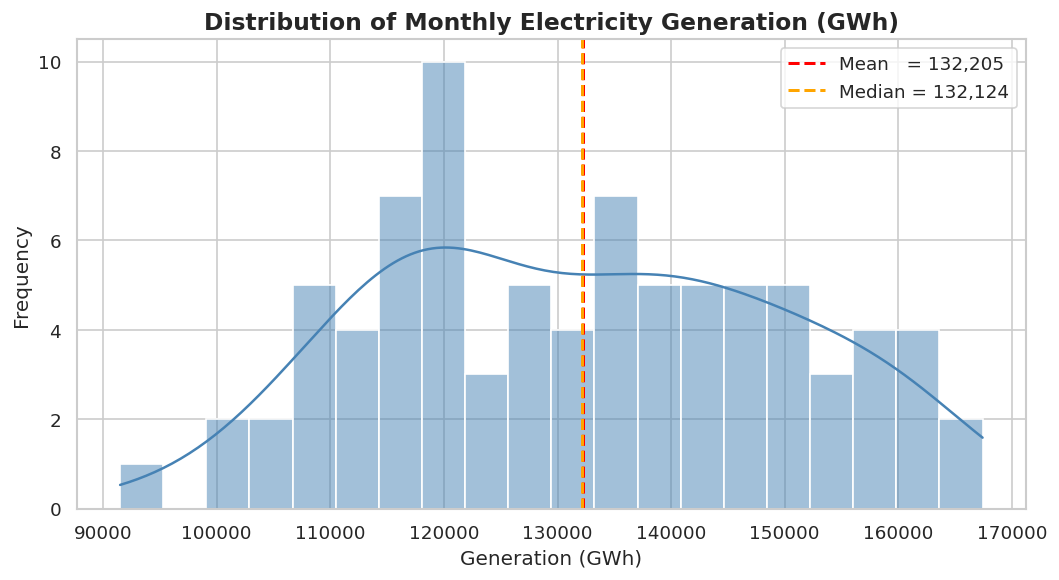

In [30]:
# Unit IV – Section 4: Distribution Plot (Histogram + KDE)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df_india['Value'], bins=20, kde=True,
             color='steelblue', edgecolor='white', ax=ax)

# Add vertical lines for mean and median
mean_val   = df_india['Value'].mean()
median_val = df_india['Value'].median()
ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.8, label=f'Mean   = {mean_val:,.0f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.8, label=f'Median = {median_val:,.0f}')

ax.set_title("Distribution of Monthly Electricity Generation (GWh)", fontweight='bold')
ax.set_xlabel("Generation (GWh)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig('plot8_distribution.png', bbox_inches='tight')
plt.show()


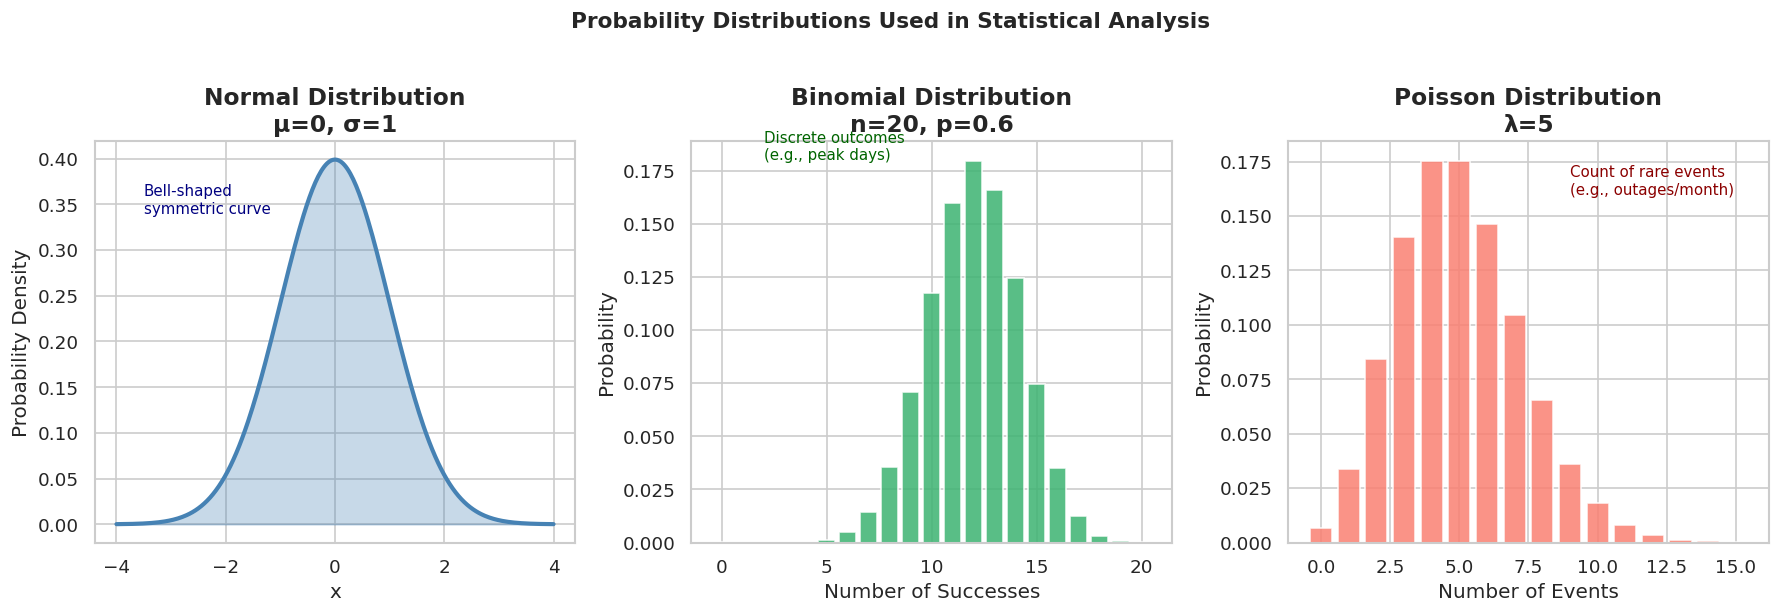

In [31]:
# Unit V – Section 4: Probability Distributions (Visual Demo)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Normal Distribution ────────────────────────────────────────────────────────
x_norm = np.linspace(-4, 4, 300)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, 0, 1),
             color='steelblue', linewidth=2.5)
axes[0].fill_between(x_norm, stats.norm.pdf(x_norm, 0, 1), alpha=0.3, color='steelblue')
axes[0].set_title("Normal Distribution\nμ=0, σ=1", fontweight='bold')
axes[0].set_xlabel("x")
axes[0].set_ylabel("Probability Density")
axes[0].text(-3.5, 0.34, "Bell-shaped\nsymmetric curve", fontsize=9, color='navy')

# ── Binomial Distribution ──────────────────────────────────────────────────────
n_trials, p_success = 20, 0.6
k_values = np.arange(0, n_trials + 1)
binom_probs = stats.binom.pmf(k_values, n_trials, p_success)
axes[1].bar(k_values, binom_probs, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f"Binomial Distribution\nn={n_trials}, p={p_success}", fontweight='bold')
axes[1].set_xlabel("Number of Successes")
axes[1].set_ylabel("Probability")
axes[1].text(2, 0.18, "Discrete outcomes\n(e.g., peak days)", fontsize=9, color='darkgreen')

# ── Poisson Distribution ───────────────────────────────────────────────────────
lambda_val = 5   # avg events (e.g., power outages per month)
k_pois = np.arange(0, 16)
pois_probs = stats.poisson.pmf(k_pois, lambda_val)
axes[2].bar(k_pois, pois_probs, color='salmon', edgecolor='white', alpha=0.85)
axes[2].set_title(f"Poisson Distribution\nλ={lambda_val}", fontweight='bold')
axes[2].set_xlabel("Number of Events")
axes[2].set_ylabel("Probability")
axes[2].text(9, 0.16, "Count of rare events\n(e.g., outages/month)", fontsize=9, color='darkred')

plt.suptitle("Probability Distributions Used in Statistical Analysis", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot9_distributions.png', bbox_inches='tight')
plt.show()

